In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!find "/content/drive/MyDrive" -type f \( -iname "*.tar" \)

/content/drive/MyDrive/Colab Notebooks/kolektorsdd2-DatasetNinja.tar
/content/drive/MyDrive/Colab Notebooks/magnetic-tile-surface-defect-DatasetNinja.tar


In [3]:
# Giải nén KolektorSDD2
!mkdir -p /content/KolektorSDD2
!tar -xf "/content/drive/MyDrive/Colab Notebooks/kolektorsdd2-DatasetNinja.tar" -C "/content/KolektorSDD2"

# Giải nén Magnetic Tile
!mkdir -p /content/MagneticTile
!tar -xf "/content/drive/MyDrive/Colab Notebooks/magnetic-tile-surface-defect-DatasetNinja.tar" -C "/content/MagneticTile"

print("Đã giải nén xong!")

tar: Unexpected EOF in archive
tar: rmtlseek not stopped at a record boundary
tar: Error is not recoverable: exiting now
Đã giải nén xong!


# 01 — Dataset & EDA (Người 1)
**Đề tài:** Multi-Scale Features, Attention Gates và Boundary-Aware Loss cho phân vùng khuyết tật bề mặt nhỏ  
**Dữ liệu:** `kolektorsdd2-DatasetNinja` (1 lớp `defect`, có train/test) + `magnetic-tile-surface-defect-DatasetNinja` (5 lớp, không chia sẵn)

| Hạng mục bắt buộc | Mục trong notebook |
|---|---|
| Dataset audit | 1 |
| Phân bố positive / negative | 2 |
| Kích thước ảnh | 3 |
| Toàn vẹn mask | 4 |
| Phân phối diện tích khuyết tật | 5 |
| Định nghĩa small / medium / large | 6, 7 |
| Phân loại theo từng loại lỗi (Magnetic Tile) | 8 |
| Chia Train / Val / Test | 9 |
| Trực quan hóa + Augmentation | 10, 11 |
| Xuất `dataset_statistics.csv`, figures, `data_segmentation/` | 12 |

> **Định dạng ann:** cả hai dataset dùng Supervisely. Mỗi vùng lỗi là một **bitmap** (PNG nén zlib → base64, kèm `origin`), không phải polygon. `dataset.py` giải mã bitmap thành mask nhị phân 0/255.

## 0. Thiết lập

In [9]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)

PROJECT_DIR = Path.cwd()            # đặt notebook cùng thư mục với dataset.py
sys.path.insert(0, str(PROJECT_DIR))
import dataset as D
import run_eda_and_pipeline as P

# ---- SỬA ĐƯỜNG DẪN NẾU CẦN ----
# KSDD2_DIR   = PROJECT_DIR / "kolektorsdd2-DatasetNinja"
# MT_DIR      = PROJECT_DIR / "magnetic-tile-surface-defect-DatasetNinja"
# OUT_DIR     = PROJECT_DIR / "data_segmentation"
# FIGURES_DIR = PROJECT_DIR / "eda_figures"
# CSV_PATH    = PROJECT_DIR / "dataset_statistics.csv"
# SEED = 42
# print("Ngưỡng khuyết tật:", f"Small < {D.SMALL_MAX_PX} px² ≤ Medium ≤ {D.MEDIUM_MAX_PX} px² < Large")
# Đường dẫn dataset đã giải nén trong Colab
KSDD2_DIR = Path("/content/KolektorSDD2")
MT_DIR = Path("/content/MagneticTile")

# Các thư mục/output của project
OUT_DIR = Path("/content/data_segmentation")
FIGURES_DIR = Path("/content/eda_figures")
CSV_PATH = Path("/content/dataset_statistics.csv")

SEED = 42

print("KolektorSDD2:", KSDD2_DIR)
print("Tồn tại:", KSDD2_DIR.exists())

print("Magnetic Tile:", MT_DIR)
print("Tồn tại:", MT_DIR.exists())

print(
    "Ngưỡng khuyết tật:",
    f"Small < {D.SMALL_MAX_PX} px² ≤ "
    f"Medium ≤ {D.MEDIUM_MAX_PX} px² < Large"
)

KolektorSDD2: /content/KolektorSDD2
Tồn tại: True
Magnetic Tile: /content/MagneticTile
Tồn tại: True
Ngưỡng khuyết tật: Small < 1024 px² ≤ Medium ≤ 4096 px² < Large


## 1. Dataset audit
Với mỗi ảnh: ghép với `ann/<tên ảnh>.json`, giải mã bitmap → mask, đo diện tích, và kiểm tra:
thiếu ann · ann mồ côi · ảnh/ann hỏng · **lệch kích thước ảnh ↔ ann** · bitmap tràn biên · object rỗng · lớp lạ so với `meta.json`.

In [10]:
records, reports = P.audit_all(KSDD2_DIR, MT_DIR)
D.assign_splits(records, seed=SEED)                       # mặc định giữ tập test chính thức của KSDD2
df = D.records_to_dataframe(records, base_dir=PROJECT_DIR)
comp_df = D.components_dataframe(records)
display(df.head())
print(f"Tổng {len(df):,} mẫu hợp lệ")

  KolektorSDD2 : 541 ảnh / 1,004 ann -> hợp lệ 540 (positive 54 | negative 486) | thiếu ann 0, ann mồ côi 463, ảnh hỏng 1, ann hỏng 0
  MagneticTile : 1,344 ảnh / 1,344 ann -> hợp lệ 1,344 (positive 388 | negative 956) | thiếu ann 0, ann mồ côi 0, ảnh hỏng 0, ann hỏng 0


,sample_id,dataset_source,orig_split,split,img_path,ann_path,width,height,ann_width,ann_height,channels,aspect_ratio,is_positive,num_objects,classes,primary_class,defect_area_px,relative_defect_area_pct,num_components,largest_component_px,component_areas,size_category,boundary_perimeter_px,bbox_x1,bbox_y1,bbox_x2,bbox_y2,integrity_status
0,ksdd2_20003,KolektorSDD2,test,test,KolektorSDD2/test/img/20003.png,KolektorSDD2/test/ann/20003.png.json,229,636,229,636,3,0.3601,False,0,none,none,0,0.0,0,0,,Negative,0.0,,,,,OK
1,ksdd2_20004,KolektorSDD2,test,test,KolektorSDD2/test/img/20004.png,KolektorSDD2/test/ann/20004.png.json,230,632,230,632,3,0.3639,False,0,none,none,0,0.0,0,0,,Negative,0.0,,,,,OK
2,ksdd2_20005,KolektorSDD2,test,test,KolektorSDD2/test/img/20005.png,KolektorSDD2/test/ann/20005.png.json,229,638,229,638,3,0.3589,False,0,none,none,0,0.0,0,0,,Negative,0.0,,,,,OK
3,ksdd2_20007,KolektorSDD2,test,test,KolektorSDD2/test/img/20007.png,KolektorSDD2/test/ann/20007.png.json,229,626,229,626,3,0.3658,False,0,none,none,0,0.0,0,0,,Negative,0.0,,,,,OK
4,ksdd2_20008,KolektorSDD2,test,test,KolektorSDD2/test/img/20008.png,KolektorSDD2/test/ann/20008.png.json,229,639,229,639,3,0.3584,False,0,none,none,0,0.0,0,0,,Negative,0.0,,,,,OK


Tổng 1,884 mẫu hợp lệ


## 2. Phân bố Positive / Negative

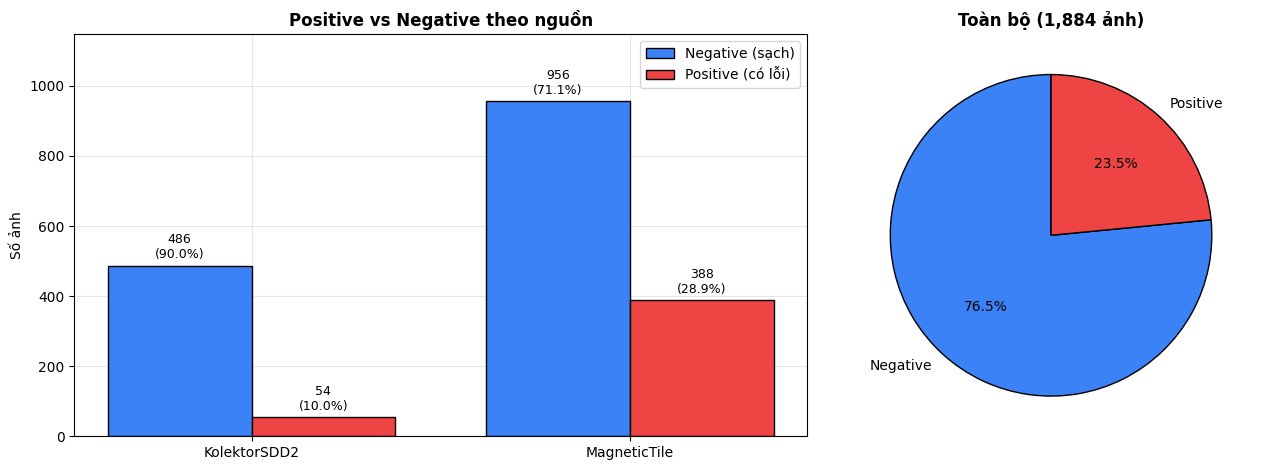

is_positive,Negative,Positive,All,% Positive
dataset_source,,,,
KolektorSDD2,486,54,540,10.0
MagneticTile,956,388,1344,28.9
All,1442,442,1884,23.5


In [11]:
fig = P.plot_pos_neg(df); plt.show()
t = pd.crosstab(df.dataset_source, df.is_positive.map({True: "Positive", False: "Negative"}), margins=True)
t["% Positive"] = (100 * t["Positive"] / t["All"]).round(1)
display(t)

**Nhận xét (điền sau khi chạy):** tỷ lệ positive của từng nguồn là bao nhiêu? Mất cân bằng lớp ảnh hưởng thế nào đến việc chọn loss (Dice / Focal / Boundary) và chiến lược lấy mẫu?

## 3. Kích thước ảnh

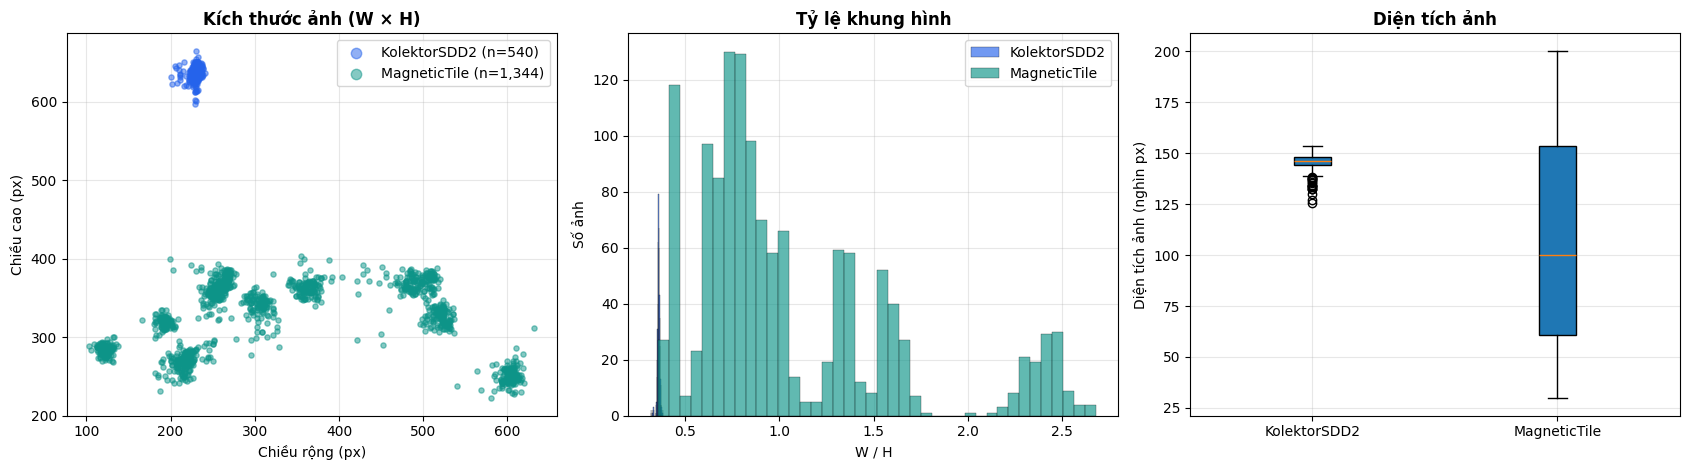

dataset_source      KolektorSDD2  MagneticTile
width        count        540.00       1344.00
             mean         229.29        330.55
             std            4.43        152.73
             min          201.00        103.00
             25%          228.00        214.00
             50%          230.00        270.50
             75%          231.00        493.25
             max          241.00        632.00
height       count        540.00       1344.00
             mean         636.31        319.59
             std            7.44         43.93
             min          597.00        222.00
             25%          632.00        279.00
             50%          637.00        324.00
             75%          641.00        360.00
             max          665.00        403.00
aspect_ratio count        540.00       1344.00
             mean           0.36          1.05
             std            0.01          0.55
             min            0.32          0.36
             25%            0.36          0.70
             50%            0.36          0.85
             75%            0.36          1.34
             max            0.38          2.68

Số kích thước (W×H) khác nhau:


,size
dataset_source,
KolektorSDD2,272
MagneticTile,1225


In [12]:
fig = P.plot_image_size(df); plt.show()
display(df.groupby("dataset_source")[["width", "height", "aspect_ratio"]].describe().T.round(2))
print("Số kích thước (W×H) khác nhau:")
display(df.assign(size=df.width.astype(str) + "×" + df.height.astype(str)).groupby("dataset_source")["size"].nunique())

**Nhận xét:** ảnh có kích thước thay đổi nên khi huấn luyện cần `target_size` cố định (hoặc pad/crop). Với khuyết tật nhỏ, cân nhắc crop thay vì resize mạnh vì resize làm mất vùng lỗi vài pixel.

## 4. Toàn vẹn mask

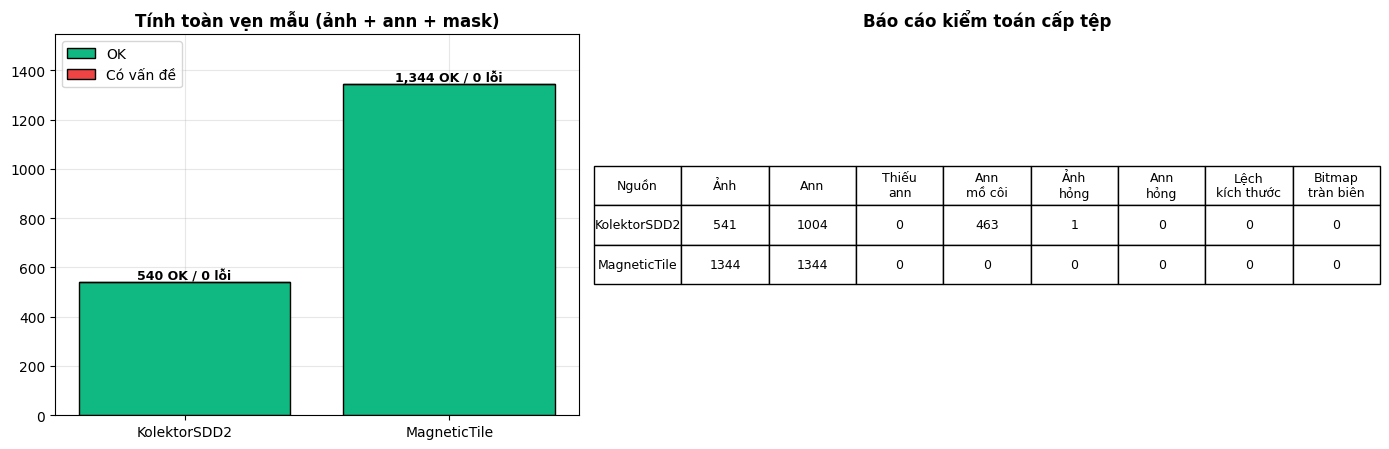

0 mẫu có vấn đề


,sample_id,dataset_source,width,height,ann_width,ann_height,integrity_status


[KolektorSDD2] orphan_ann: 463 -> ví dụ ['test/ann/20000.png.json', 'test/ann/20001.png.json', 'test/ann/20002.png.json']
[KolektorSDD2] corrupt_images: 1 -> ví dụ ['test/img/20881.png']


In [13]:
fig = P.plot_mask_integrity(df, reports); plt.show()
bad = df[df.integrity_status != "OK"]
print(f"{len(bad)} mẫu có vấn đề"); display(bad[["sample_id", "dataset_source", "width", "height", "ann_width", "ann_height", "integrity_status"]])
for src, r in reports.items():
    for k in ("missing_ann", "orphan_ann", "corrupt_images", "bad_ann_json"):
        if r[k]: print(f"[{src}] {k}: {len(r[k])} -> ví dụ {r[k][:3]}")

## 5. Phân phối diện tích khuyết tật

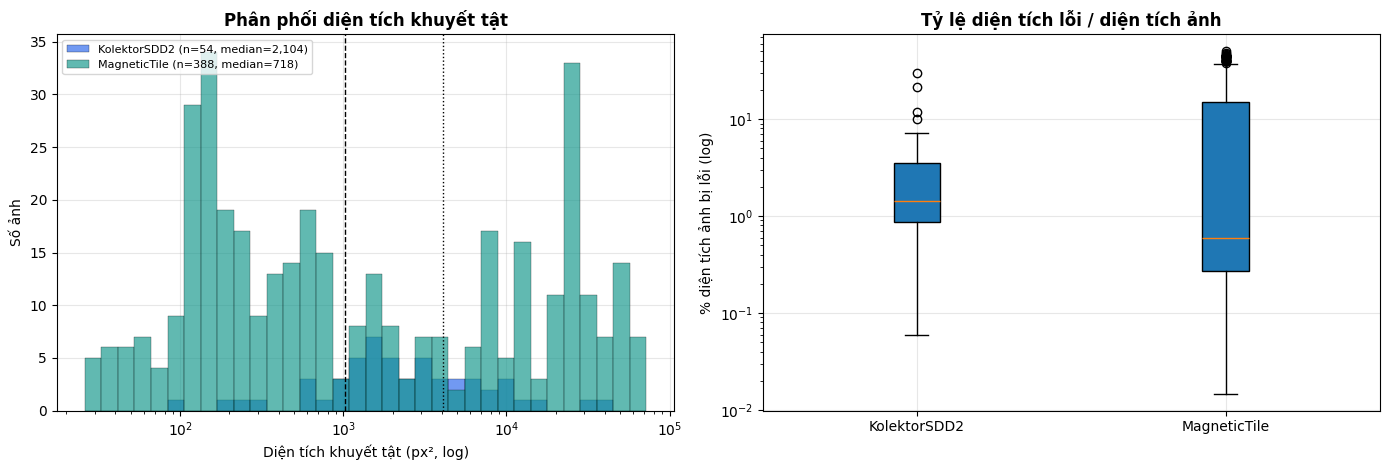

dataset_source                  KolektorSDD2  MagneticTile
defect_area_px           count        54.000       388.000
                         mean       4777.704      9341.995
                         std        7546.905     15815.307
                         min          87.000        26.000
                         10%         613.200       106.700
                         25%        1285.750       163.500
                         50%        2103.500       718.500
                         75%        5227.250     12077.500
                         90%       10304.400     28731.200
                         max       43869.000     72048.000
relative_defect_area_pct count        54.000       388.000
                         mean          3.274         9.045
                         std           5.164        13.769
                         min           0.060         0.015
                         10%           0.431         0.104
                         25%           0.862         0.273
                         50%           1.443         0.596
                         75%           3.561        15.104
                         90%           7.037        34.620
                         max          30.158        49.808
num_components           count        54.000       388.000
                         mean          1.093         1.183
                         std           0.351         0.593
                         min           1.000         1.000
                         10%           1.000         1.000
                         25%           1.000         1.000
                         50%           1.000         1.000
                         75%           1.000         1.000
                         90%           1.000         2.000
                         max           3.000         6.000

In [14]:
fig = P.plot_defect_area(df); plt.show()
pos = df[df.is_positive]
display(pos.groupby("dataset_source")[["defect_area_px", "relative_defect_area_pct", "num_components"]]
        .describe(percentiles=[.1, .25, .5, .75, .9]).T.round(3))

## 6. Định nghĩa Small / Medium / Large
Tính trên **tổng diện tích khuyết tật trong ảnh** (px²):

| Nhóm | Diện tích |
|---|---|
| Small | < 1 024 px² |
| Medium | 1 024 – 4 096 px² |
| Large | > 4 096 px² |

ECDF bên dưới cho biết các ngưỡng này nằm ở đâu trên phân phối thực tế. Nếu một nhóm quá ít mẫu thì đổi `SMALL_MAX_PX` / `MEDIUM_MAX_PX` trong `dataset.py`.

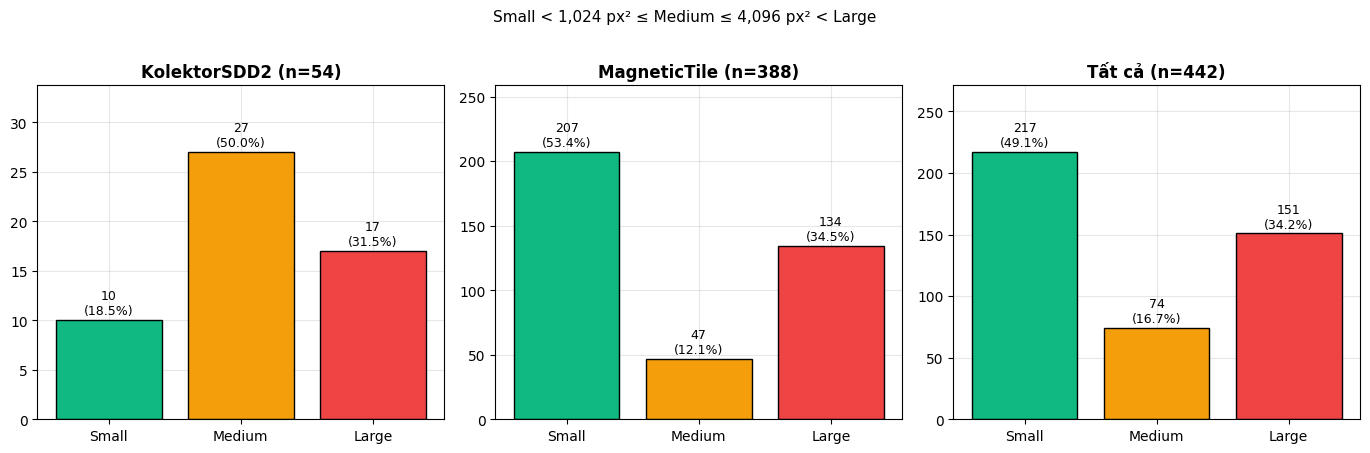

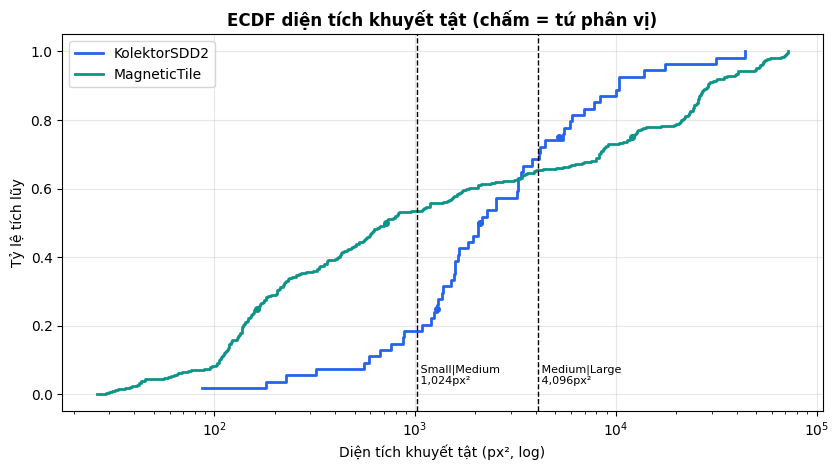

,0.10,0.25,0.50,0.75,0.90
dataset_source,,,,,
KolektorSDD2,613.0,1286.0,2104.0,5227.0,10304.0
MagneticTile,107.0,164.0,718.0,12078.0,28731.0


Độ nhạy theo ngưỡng Small (% ảnh positive có diện tích nhỏ hơn ngưỡng):


ngưỡng px²,256,512,1024,2048
dataset_source,,,,
KolektorSDD2,5.6,7.4,18.5,46.3
MagneticTile,34.3,43.8,53.4,60.3


In [15]:
fig = P.plot_size_categories(df); plt.show()
fig = P.plot_area_ecdf(df); plt.show()
q = pos.groupby("dataset_source").defect_area_px.quantile([.1, .25, .5, .75, .9]).unstack().round(0)
display(q)
print("Độ nhạy theo ngưỡng Small (% ảnh positive có diện tích nhỏ hơn ngưỡng):")
display(pd.DataFrame({thr: pos.groupby("dataset_source").defect_area_px.apply(lambda s, t=thr: round(100 * (s < t).mean(), 1))
                      for thr in (256, 512, 1024, 2048)}).rename_axis("ngưỡng px²", axis=1))

## 7. Phân tích ở mức từng vùng lỗi liên thông

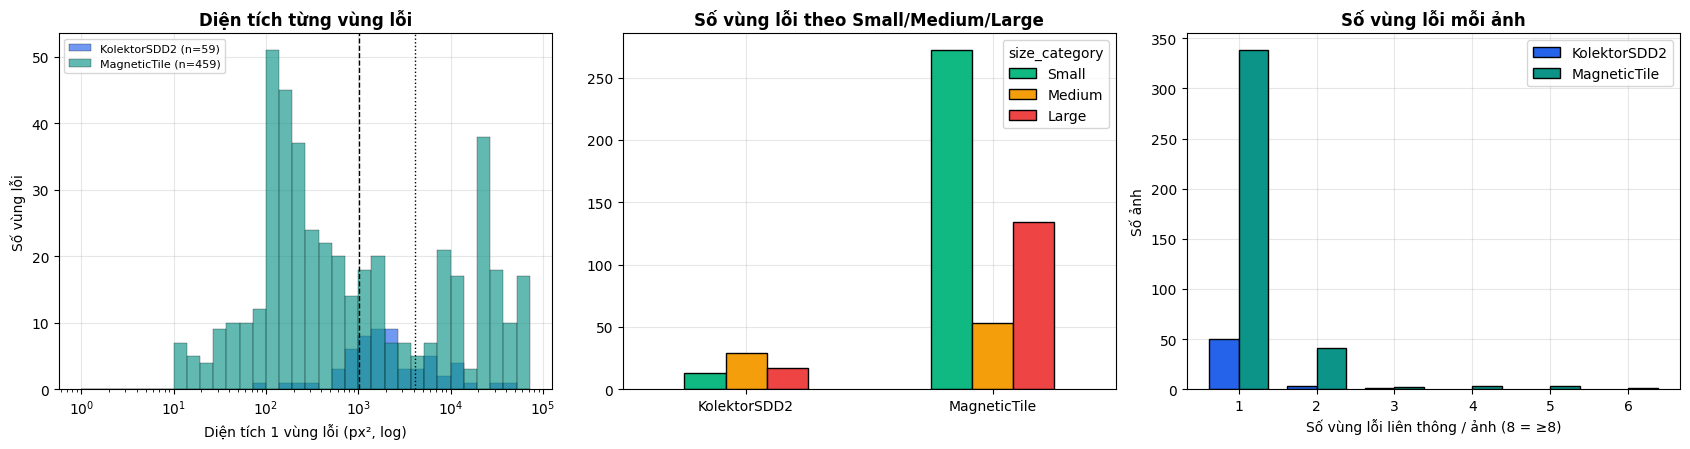

,count,mean,std,min,25%,50%,75%,max
dataset_source,,,,,,,,
KolektorSDD2,59.0,4372.8,7312.3,87.0,1159.0,1843.0,4314.5,43869.0
MagneticTile,459.0,7896.9,14905.1,11.0,146.0,478.0,8290.5,72048.0


In [16]:
fig = P.plot_components(df, comp_df); plt.show()
display(comp_df.groupby("dataset_source").component_area_px.describe().round(1))

## 8. Magnetic Tile — theo loại khuyết tật

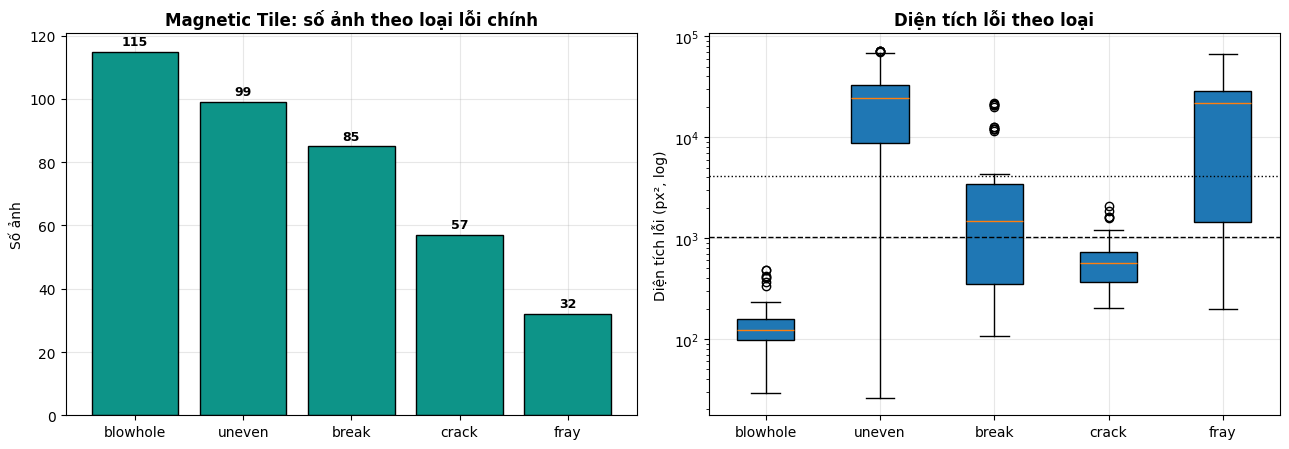

,count,mean,std,min,25%,50%,75%,max
primary_class,,,,,,,,
blowhole,115.0,137.0,87.0,29.0,96.0,123.0,158.0,483.0
break,85.0,3672.0,5760.0,108.0,353.0,1479.0,3421.0,21964.0
crack,57.0,643.0,405.0,204.0,363.0,566.0,729.0,2063.0
fray,32.0,22327.0,20029.0,198.0,1441.0,22043.0,28741.0,66826.0
uneven,99.0,25713.0,18308.0,26.0,8760.0,24627.0,33122.0,72048.0


Ảnh có >1 loại lỗi: 0


In [17]:
fig = P.plot_mt_classes(df)
if fig is not None:
    plt.show()
    mt = df[(df.dataset_source == "MagneticTile") & df.is_positive]
    display(mt.groupby("primary_class").defect_area_px.describe().round(0))
    print("Ảnh có >1 loại lỗi:", int((mt.classes.str.contains(r"\|")).sum()))

## 9. Chia Train / Val / Test
* **KolektorSDD2:** giữ nguyên tập test chính thức (để so sánh với các công bố khác); tách `val` từ train.
* **Magnetic Tile:** không có split gốc → chia 70/15/15.
* Phân tầng theo (nguồn, positive/negative, Small/Medium/Large, loại lỗi chính).  
  Muốn chia lại KSDD2 theo 70/15/15: `D.assign_splits(records, respect_official=False)`.

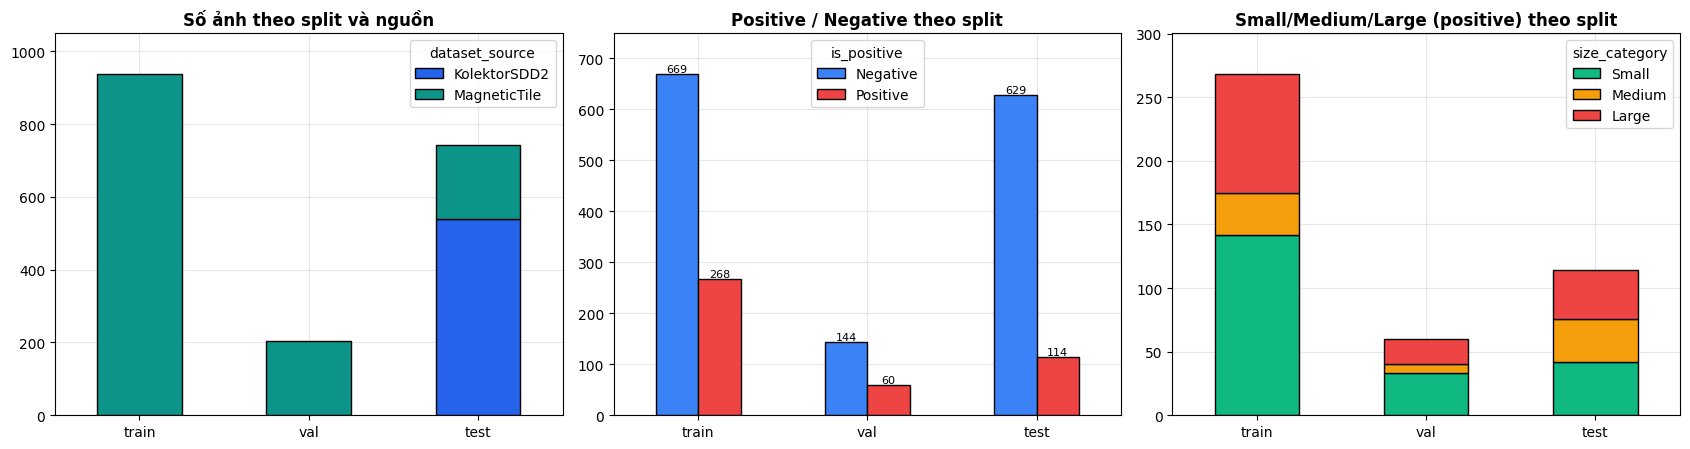

split                       test  train  val   All
dataset_source is_positive                        
KolektorSDD2   False         486      0    0   486
               True           54      0    0    54
MagneticTile   False         143    669  144   956
               True           60    268   60   388
All                          743    937  204  1884

size_category,Large,Medium,Small
split (positive) — tỷ lệ Small/Medium/Large,,,
test,0.333,0.298,0.368
train,0.347,0.123,0.530
val,0.333,0.117,0.550


In [18]:
D.assign_splits(records, seed=SEED, respect_official=True)
df = D.records_to_dataframe(records, base_dir=PROJECT_DIR)
fig = P.plot_splits(df); plt.show()
display(pd.crosstab([df.dataset_source, df.is_positive], df.split, margins=True))
display(pd.crosstab(df[df.is_positive].split, df[df.is_positive].size_category, normalize="index").round(3)
        .rename_axis("split (positive) — tỷ lệ Small/Medium/Large"))

Tùy chọn: kiểm tra ảnh gần trùng giữa các split (rò rỉ dữ liệu). Bỏ comment để chạy (mất vài phút với ~4 000 ảnh).

In [19]:
pairs = D.find_near_duplicates(records, max_hamming=2)
by_id = {r.sample_id: r for r in records}
leak = [p for p in pairs if by_id[p[0]].split != by_id[p[1]].split]
print(len(pairs), "cặp gần trùng;", len(leak), "cặp nằm ở split khác nhau")

39 cặp gần trùng; 21 cặp nằm ở split khác nhau


## 10. Trực quan hóa: ảnh · mask · overlay · boundary map

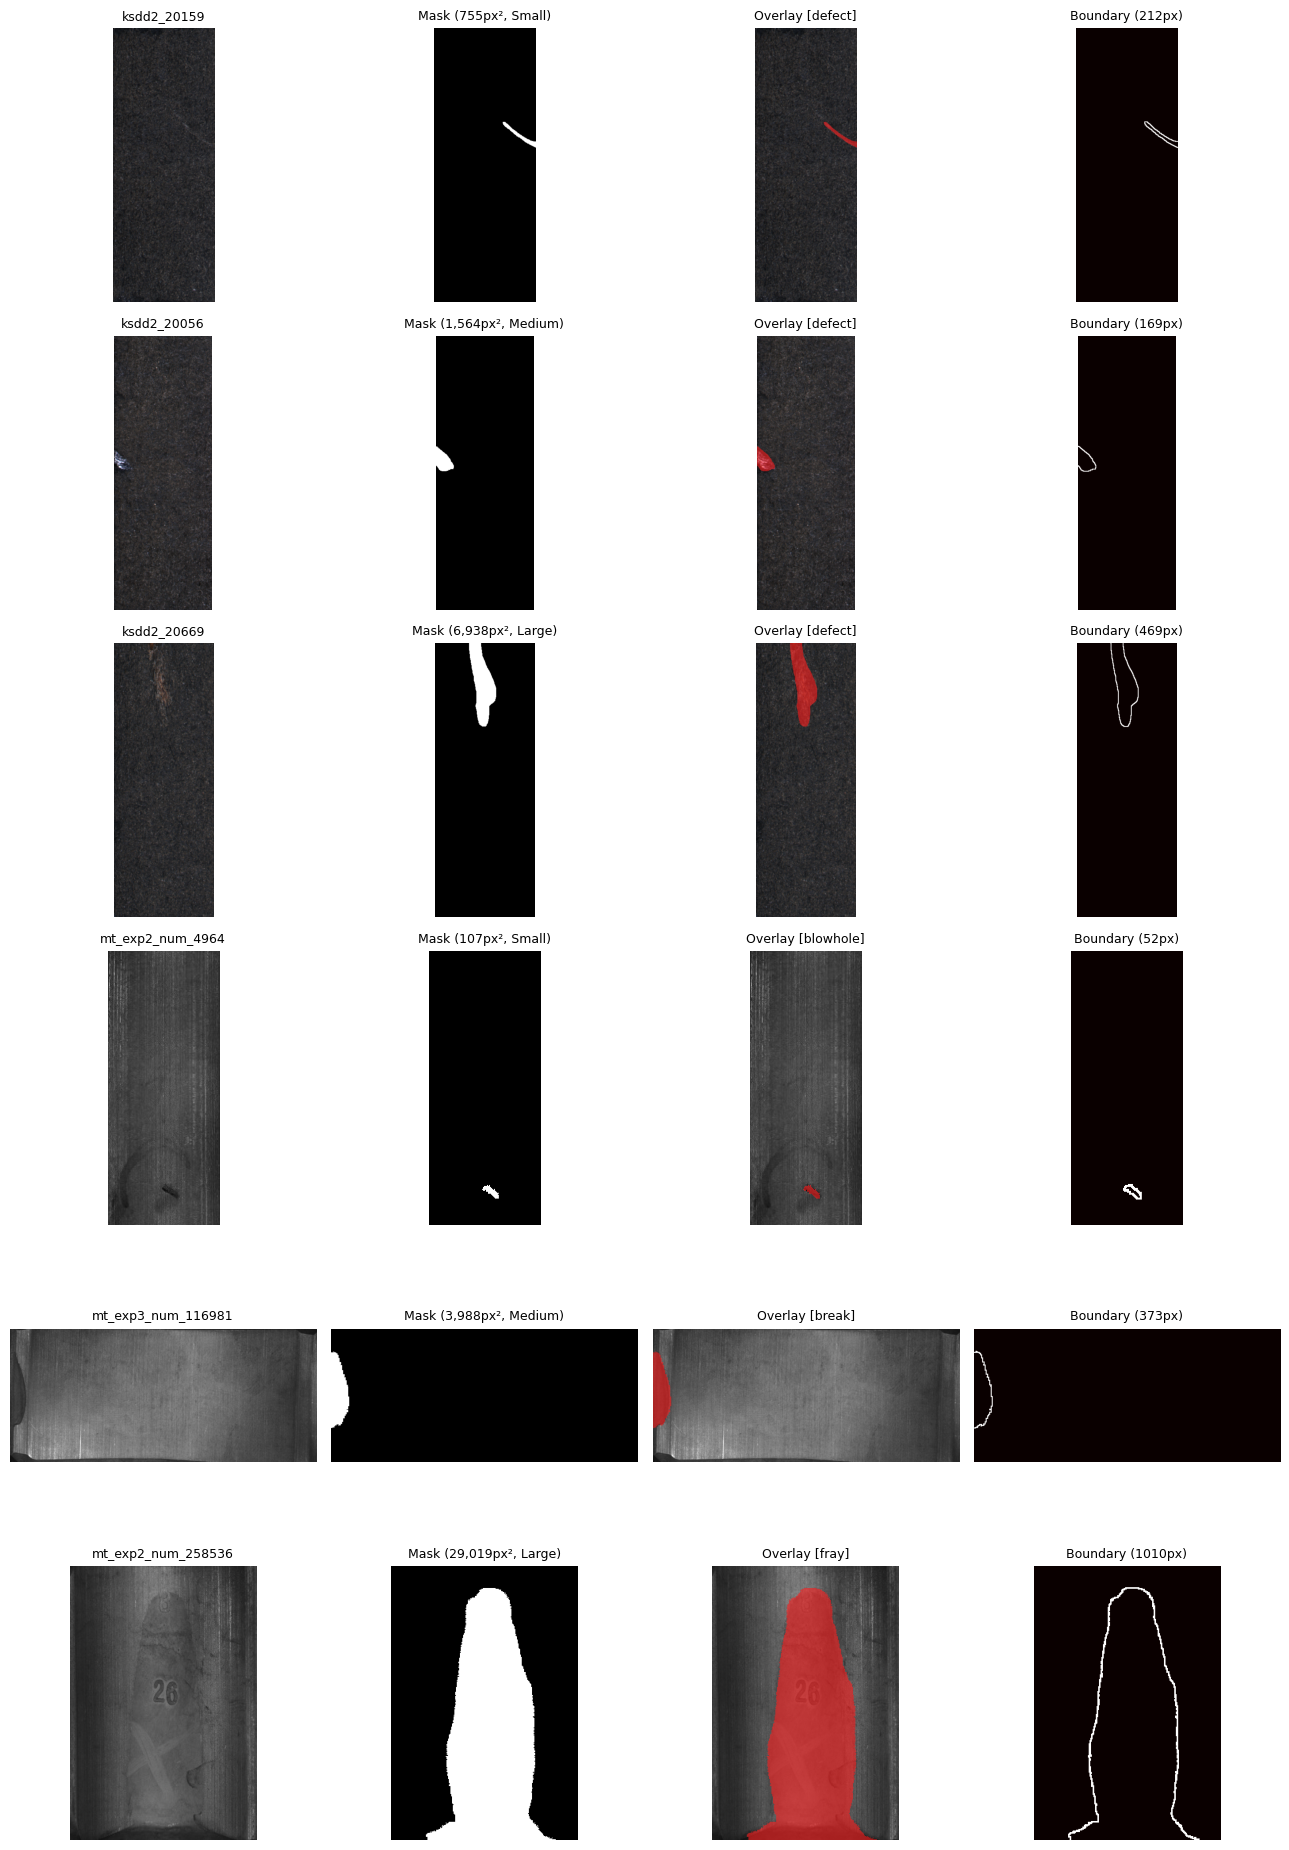

In [20]:
fig = P.plot_samples([r for r in records if r.is_positive], per_group=1, seed=SEED)
if fig is not None: plt.show()

## 11. Augmentation đồng bộ ảnh + mask
`CoupledAugmentor`: lật ngang/dọc, xoay 90°, affine nhẹ (xoay ±15°, scale 0.9–1.1, dịch ≤5%) áp dụng **cùng lúc** lên ảnh và mask (mask dùng nearest → vẫn nhị phân); độ sáng/tương phản chỉ tác động lên ảnh.  
Augmentation chạy **online** trong `SurfaceDefectDataset(..., augment=True)` và chỉ bật cho `train`.

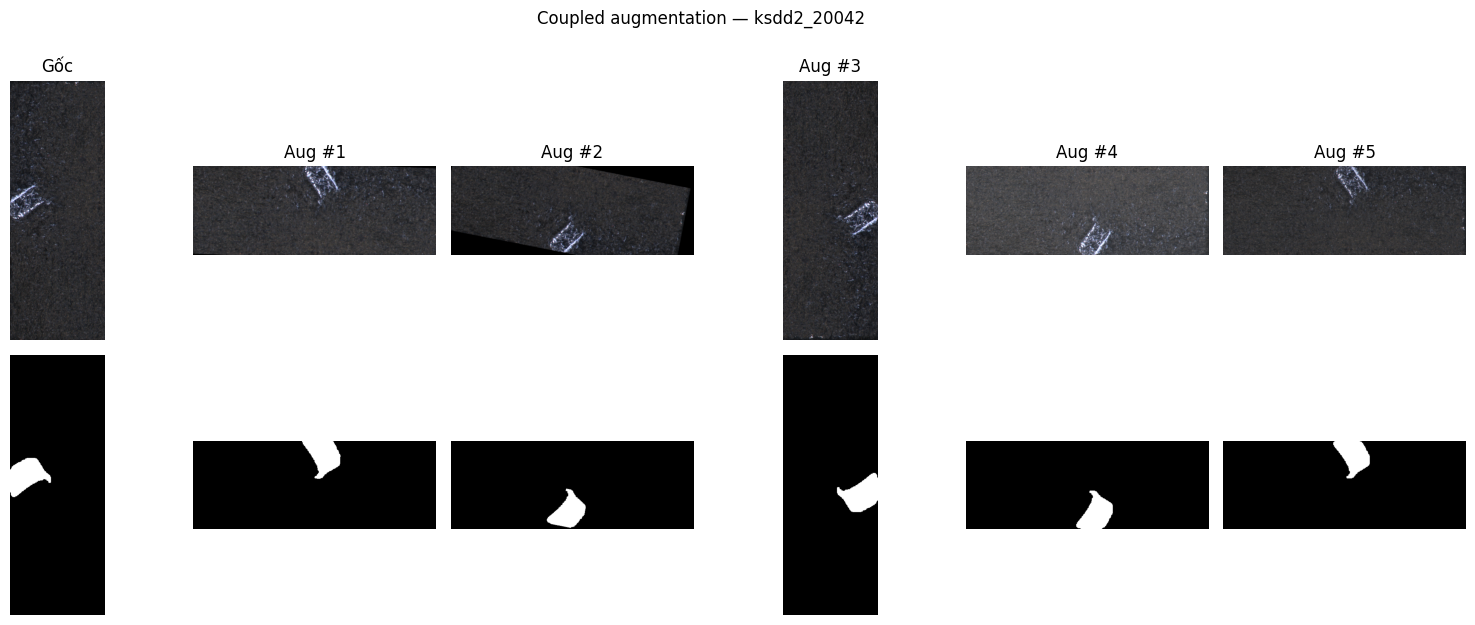

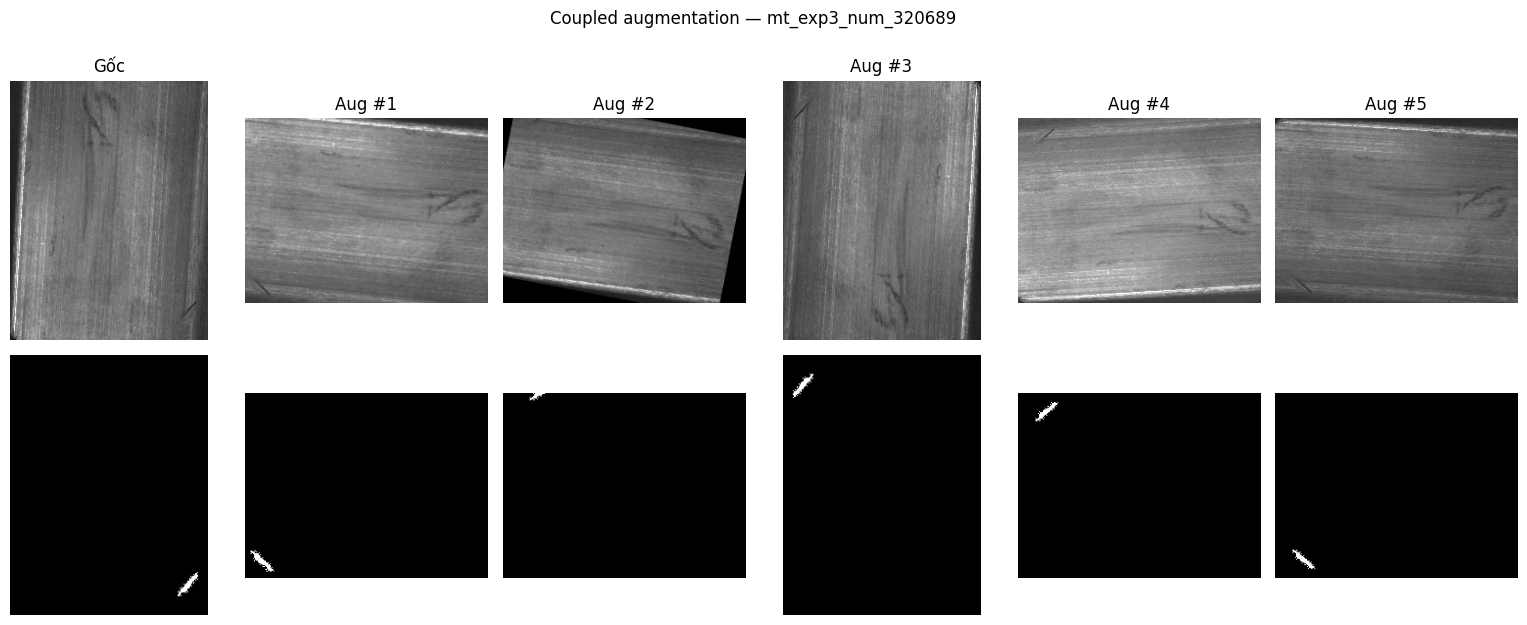

In [21]:
pos_recs = [r for r in records if r.is_positive]
for rec in (pos_recs[0], pos_recs[len(pos_recs) // 2]):
    fig = P.plot_augmentation(rec, n=5, seed=1); plt.show()

## 12. Xuất deliverables

In [22]:
df["exported"] = df.is_positive          # đổi thành True nếu include_negatives=True
df.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")
saved = P.save_all_figures(df, records, reports, comp_df, FIGURES_DIR)
print(f"Đã lưu {CSV_PATH.name} ({len(df):,} dòng) và {len(saved)} biểu đồ vào {FIGURES_DIR.name}/")

EXPORT = False          # True để tạo data_segmentation/ (chỉ ảnh có khuyết tật)
OVERWRITE = False       # True nếu muốn ghi đè train/val/test đã có
if EXPORT:
    counts = D.export_dataset(records, OUT_DIR, include_negatives=False, overwrite=OVERWRITE)
    print("Số mẫu đã xuất:", counts)
    v = D.verify_export(OUT_DIR)
    print(f"Kiểm tra: {v['n_checked']} ảnh, {len(v['problems'])} vấn đề", v["problems"][:5])

Đã lưu dataset_statistics.csv (1,884 dòng) và 11 biểu đồ vào eda_figures/


## 13. Tóm tắt số liệu

In [23]:
pos = df[df.is_positive]
print(f"Tổng mẫu: {len(df):,} | Positive: {len(pos):,} ({100*len(pos)/len(df):.1f}%) | Negative: {len(df)-len(pos):,}")
for s, g in pos.groupby("dataset_source"):
    vc = g.size_category.value_counts(normalize=True).reindex(D.SIZE_ORDER).fillna(0) * 100
    print(f"{s}: median diện tích {g.defect_area_px.median():,.0f} px² "
          f"({g.relative_defect_area_pct.median():.3f}% ảnh) | " + " | ".join(f"{k} {v:.1f}%" for k, v in vc.items()))
print("Mẫu có vấn đề toàn vẹn:", int((df.integrity_status != 'OK').sum()))

Tổng mẫu: 1,884 | Positive: 442 (23.5%) | Negative: 1,442
KolektorSDD2: median diện tích 2,104 px² (1.443% ảnh) | Small 18.5% | Medium 50.0% | Large 31.5%
MagneticTile: median diện tích 718 px² (0.596% ảnh) | Small 53.4% | Medium 12.1% | Large 34.5%
Mẫu có vấn đề toàn vẹn: 0
